# Session 2 — Introduction to digital images

We will learn how to manipulate and visualize digital images. We will get familiar with the main image formats and state-of-the-art image processing libraries including: OpenCV, scikit-image, Mahotas, Matplotlib, and Pillow.

## Learning objectives
- Read, display, and save images using OpenCV, scikit-image, and Pillow.
- Understand color-channel ordering (BGR vs. RGB) and dtype/range conventions across libraries.
- Reason about the memory footprint of a decoded image array vs. its compressed size on disk (JPEG).
- Convert RGB images to grayscale, manually and with library functions, and apply Otsu thresholding.
- Perform basic geometric transforms (rotation) and use an external image viewer (vpv).

## Exercises
- **Ex1**: Convert an OpenCV (BGR) image to RGB for display, and reason about its memory footprint on disk vs. decoded in memory.
- **Ex2**: Convert an RGB image to grayscale by averaging channels, and compare it to scikit-image's `rgb2gray`.
- **Ex3**: Compute Otsu thresholding with Mahotas.
- **Ex4**: Rotate an image 90 degrees with Pillow.
- **Ex5**: Install and use the `vpv` image viewer.


### Environment setup
This session uses the shared course environment — there is no separate `requirements.txt` in this folder. Follow the setup instructions in the repo-root [README.md](../README.md) (create/activate the `dlfcv2025` conda environment and run `pip install -r requirements.txt` from the repo root) before running this notebook.

## OpenCV

In [12]:
import cv2
import matplotlib.pyplot as plt

# Check cv2 version
print(cv2.__version__)
# Read a test image
img = cv2.imread("data/test1.jpg")
assert img is not None, "check the image path"

4.10.0


### Exercise 1 (a)
Show this image using matplotlib.

Hint: OpenCV represents images as BGR, but matplotlib uses RGB.

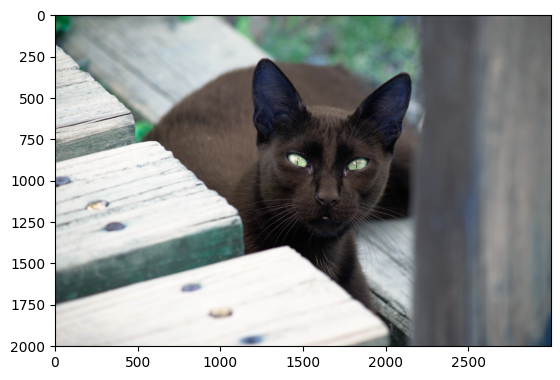

In [13]:
imgplot = plt.imshow(img)

In [4]:
cv2.imshow("diplay image",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Exercise 1 (b)
- (b1) Estimate the number of bytes `img` takes if its data type is `uint8`.
- (b2) Print the actual memory usage of the array.
- (b3) Is `test1.jpg` taking the same space on disk? If not, explain the difference.

In [14]:
import math
#b1
img_size=img.shape
mb_size = math.prod(img_size)
print(f" Size in bytes {mb_size} bytes")
print(f" Size in Mb {mb_size/1024/1024} Mb")

 Size in bytes 18027000 bytes
 Size in Mb 17.19188690185547 Mb


In [15]:
#b2
from sys import __sizeof__
img.__sizeof__()

18027144

## Scikit-image

In [16]:
import skimage as ski

# Read the image
original = ski.io.imread("data/test4.jpg")

### Exercise 2 (a)
Define the grayscale image by averaging the RGB channels, and compare it to scikit-image's `rgb2gray`.

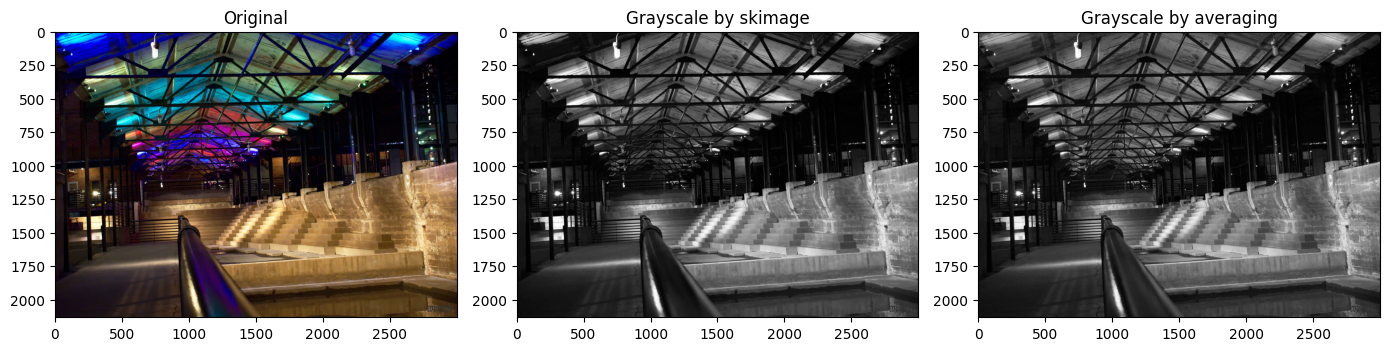

In [17]:
# Display the original image and the grayscale one
from skimage.color import rgb2gray

skimage_grayscale = rgb2gray(original)

avg_grayscale = original.mean(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ax = axes.ravel()
ax[0].imshow(original)
ax[0].set_title("Original")
ax[1].imshow(skimage_grayscale, cmap=plt.cm.gray)
ax[1].set_title("Grayscale by skimage")
ax[2].imshow(avg_grayscale, cmap=plt.cm.gray)
ax[2].set_title("Grayscale by averaging")
fig.tight_layout()
plt.show()

**Note (dtype/range trap):** `rgb2gray` returns a `float64` image scaled to `[0, 1]`, while `original.mean(axis=2)` returns a `float64` image scaled to `[0, 255]` (the same range as the input `uint8` image). `imshow` autoscales each image independently by default, so both grayscale panels above look the same even though the underlying pixel values live on completely different scales — always check `.dtype` / `.min()` / `.max()` before comparing arrays numerically.

In [19]:
print(f"Original image shape: {avg_grayscale.shape}")
print(f"Original image type: {avg_grayscale.dtype}")
print(f"Original image min: {avg_grayscale.min()}")
print(f"Original image max: {avg_grayscale.max()}")

Original image shape: (2133, 3000)
Original image type: float64
Original image min: 0.0
Original image max: 255.0


In [20]:
print(f"Scikit image shape: {skimage_grayscale.shape}")
print(f"Scikit image type:{skimage_grayscale.dtype}")
print(f"Scikit image min: {skimage_grayscale.min()}")
print(f"Scikit image max: {skimage_grayscale.max()}")

Scikit image shape: (2133, 3000)
Scikit image type:float64
Scikit image min: 0.0
Scikit image max: 1.0


### Exercise 2 (b)
How is skimage's grayscale different from the one you defined?

#### AI generate
Scikit-image does not compute "mean grayscale" directly. When converting to grayscale, scikit-image uses weighted mean (luminosity), not a simple arithmetic mean. The default method in rgb2gray() is 'rgb' (weighted average using ITU-R BT.601 coefficients).
Scikit-image does not compute "mean grayscale" directly. When converting to grayscale, scikit-image uses weighted mean (luminosity), not a simple arithmetic mean. The default method in rgb2gray() is 'rgb' (weighted average using ITU-R BT.601 coefficients),

## Mahotas

### Exercise 3
Use mahotas tools to compute Otsu thresholding and display the result.

Otsu threshold value: 155


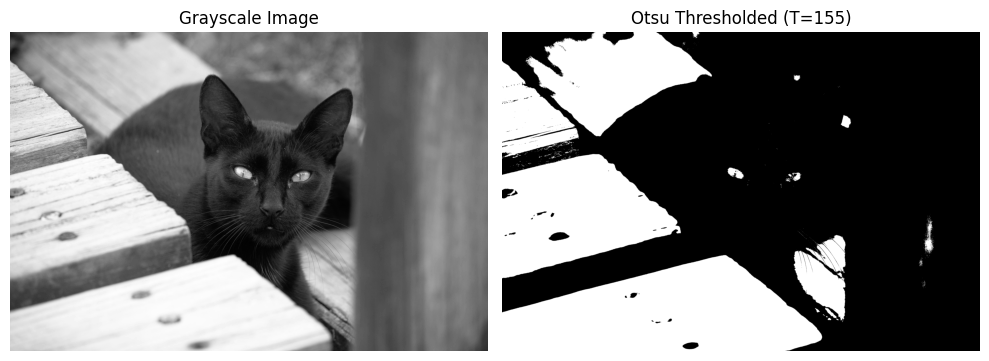

In [21]:
import mahotas as mh
import numpy as np
import matplotlib.pyplot as plt

image = mh.imread("data/test1.jpg")  # read image
image = image.mean(axis=2)  # convert to grayscale by channel average
image = image.astype(np.uint8)  # convert to uint8
# 2. Compute the Otsu threshold
otsu_threshold = mh.otsu(image)
print(f"Otsu threshold value: {otsu_threshold}")
# 3. Apply the threshold to get a binary mask
binary_image = image > otsu_threshold
# 4. Display the original grayscale image and the binarized result side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original grayscale image
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")
# Binary thresholded image
axes[1].imshow(binary_image, cmap="gray")
axes[1].set_title(f"Otsu Thresholded (T={otsu_threshold})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Pillow

### Exercise 4
Use Pillow to rotate the image 90 degrees and display the result.

JPEG (2984, 3000) RGB


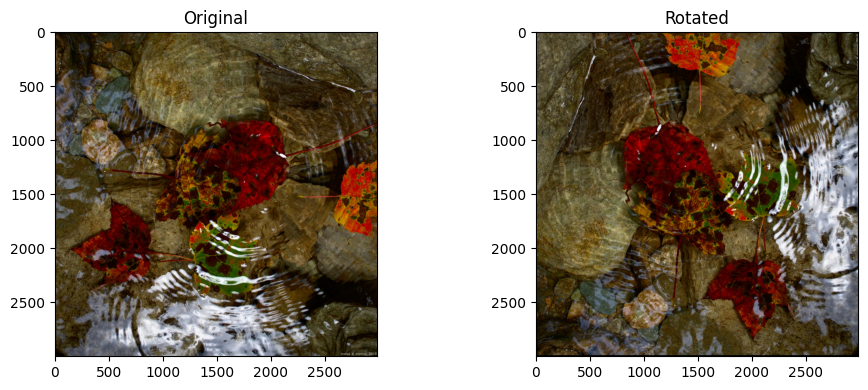

In [22]:
from PIL import Image

original = Image.open("data/test3.jpg")
# Print the image format, size and mode
print(original.format, original.size, original.mode)

rotated = original.rotate(90)
# Print the image

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()
ax[0].imshow(original)
ax[0].set_title("Original")
ax[1].imshow(rotated)
ax[1].set_title("Rotated")
fig.tight_layout()
plt.show()

## Saving images
Once you've processed an image, you'll usually want to write it back to disk. Both OpenCV and scikit-image provide simple save functions, but mind the channel order: `cv2.imwrite` expects BGR (matching `cv2.imread`), while `ski.io.imsave` expects RGB.

In [25]:
import tempfile
import cv2

out_dir = tempfile.mkdtemp()

# cv2.imwrite expects BGR-ordered arrays (matches what cv2.imread returns)
cv2.imwrite(f"{out_dir}/test1_cv2.jpg", img)

# ski.io.imsave expects RGB-ordered arrays
ski.io.imsave(f"{out_dir}/test1_skimage.jpg", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

print(f"Saved images to {out_dir}")

Saved images to C:\Users\rodri\AppData\Local\Temp\tmpvt5ymlux


## Check and install vpv 
https://github.com/kidanger/vpv

### Exercise 5
Install vpv and visualize images like a pro ;)

Visualize the images in the `../TestImages` folder and compare the noisy and denoised versions. Check the different layouts and get familiar with the visualization tool vpv.